#### Celda 0: Verificación de Entorno

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib as mpl
import seaborn as sns
import sklearn

print("====================================================")
print("     📋 FISIMART S.A.C. - CHECKLIST DE ENTORNO     ")
print("====================================================")
print(f"Versión de Python:       {sys.version.split()[0]}")
print(f"Versión de Pandas:       {pd.__version__}")
print(f"Versión de NumPy:        {np.__version__}")
print(f"Versión de Matplotlib:   {mpl.__version__}")
print(f"Versión de Seaborn:      {sns.__version__}")
print(f"Versión de Scikit-Learn: {sklearn.__version__}")
print("====================================================")
print("✅ ¡Todas las librerías necesarias están listas para operar!")

     📋 FISIMART S.A.C. - CHECKLIST DE ENTORNO     
Versión de Python:       3.11.1
Versión de Pandas:       2.3.3
Versión de NumPy:        2.4.6
Versión de Matplotlib:   3.10.9
Versión de Seaborn:      0.13.2
Versión de Scikit-Learn: 1.8.0
✅ ¡Todas las librerías necesarias están listas para operar!


#### Celda 1: Importación de Librerías y Estilo Corporativo

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# Ajustar parámetros de visualización global (estilo limpio y profesional, consistente con la Parte 2)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paleta corporativa oficial de FISIMart
PALETA_FISIMART = ["#1f77b4", "#aec7e8", "#ff7f0e", "#ffbb78", "#4d4d4d"]
sns.set_palette(sns.color_palette(PALETA_FISIMART))

# Semilla fija del proyecto, consistente con la convención ya usada en partes anteriores
SEMILLA = 20

# Crear el directorio físico para los reportes visuales respetando la estructura del proyecto
os.makedirs('../reports/figures', exist_ok=True)
print("⚙️ Estilos ejecutivos, librerías de Machine Learning y carpetas de destino configurados correctamente.")

⚙️ Estilos ejecutivos, librerías de Machine Learning y carpetas de destino configurados correctamente.


#### Celda 2: Recuperación de `df_master` (Consolidado en la Parte 2)

Esta celda **no introduce ningún cambio en el proceso ETL**. Reconstruye `df_master` ejecutando exactamente el mismo proceso de carga y unificación en modelo estrella ya validado y aprobado en la Parte 2, únicamente para que este notebook de la Parte 3 pueda ejecutarse de forma independiente y de principio a fin. No se agrega, elimina ni transforma ninguna columna adicional respecto a lo ya construido.

In [3]:
# Carga de los DataMarts generados en la fase de ETL con las rutas y delimitadores correctos
df_ventas = pd.read_csv('../data/processed/Fact_Ventas.csv', delimiter=';')
df_productos = pd.read_csv('../data/processed/Dim_Producto.csv', delimiter=';')
df_clientes = pd.read_csv('../data/processed/Dim_Cliente.csv', delimiter=';')
df_promocion = pd.read_csv('../data/processed/Dim_Promocion.csv', delimiter=';')
df_tiempo = pd.read_csv('../data/processed/Dim_Tiempo.csv', delimiter=';')
df_tiendas = pd.read_csv('../data/processed/Dim_Tienda.csv', delimiter=';')

# 1. Convertimos todas las columnas a minúsculas
for df in [df_ventas, df_productos, df_clientes, df_promocion, df_tiempo, df_tiendas]:
    df.columns = df.columns.str.lower()

# 2. Renombrado Preventivo para evitar colisiones de columnas repetidas (como 'nombre' o 'descripcion')
if 'nombre' in df_productos.columns:
    df_productos = df_productos.rename(columns={'nombre': 'nombre_producto'})
if 'nombre' in df_clientes.columns:
    df_clientes = df_clientes.rename(columns={'nombre': 'nombre_cliente'})
if 'nombre' in df_tiendas.columns:
    df_tiendas = df_tiendas.rename(columns={'nombre': 'nombre_tienda'})
if 'nombre' in df_promocion.columns:
    df_promocion = df_promocion.rename(columns={'nombre': 'nombre_promocion'})

# 3. Asegurar el parseo correcto de variables temporales basándose en la columna 'fecha'
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
df_ventas['anio_mes'] = df_ventas['fecha'].dt.to_period('M')
df_clientes['fecha_alta'] = pd.to_datetime(df_clientes['fecha_alta'])

# 4. MERGE INTEGRAL LIBRE DE ERRORES: Consolidamos el Modelo Estrella sin colisiones
df_master = pd.merge(df_ventas, df_productos, on='id_producto', how='left')
df_master = pd.merge(df_master, df_clientes, on='id_cliente', how='left')
df_master = pd.merge(df_master, df_promocion, on='id_promocion', how='left')
df_master = pd.merge(df_master, df_tiendas, on='id_tienda', how='left')

print("¡df_master recuperado con éxito, heredado de la Parte 2!")
print(f"Total de transacciones disponibles para el modelado: {df_master.shape[0]}")
print(f"Total de clientes distintos con al menos una transacción histórica: {df_master['id_cliente'].nunique()}")

¡df_master recuperado con éxito, heredado de la Parte 2!
Total de transacciones disponibles para el modelado: 25413
Total de clientes distintos con al menos una transacción histórica: 3641


#### Celda 3: Definición de Parámetros Temporales y Segmentación de Ventanas

Según el diseño metodológico aprobado, el informe define el patrón de abandono como el cese total de actividad de compra durante los **últimos cuatro meses de 2025**. Esto fija dos ventanas mutuamente excluyentes:

- **Ventana de observación** (`fecha <= 2025-08-31`): única fuente permitida para calcular variables predictoras.
- **Ventana de resultado** (`2025-09-01` a `2025-12-31`): única fuente permitida para construir la etiqueta `churn`.

Esta segmentación se aplica **antes** de cualquier agregación, para blindar el pipeline contra fuga de información temporal.

In [4]:
FECHA_CORTE = pd.Timestamp('2025-08-31')
INICIO_RESULTADO = pd.Timestamp('2025-09-01')
FIN_RESULTADO = pd.Timestamp('2025-12-31')

# Subconjunto de observación: única fuente permitida para las variables predictoras
df_obs = df_master[df_master['fecha'] <= FECHA_CORTE].copy()

# Subconjunto de resultado: única fuente permitida para la etiqueta churn
df_resultado = df_master[
    (df_master['fecha'] >= INICIO_RESULTADO) & (df_master['fecha'] <= FIN_RESULTADO)
].copy()

print(f"Fecha de corte de observación:            {FECHA_CORTE.date()}")
print(f"Ventana de resultado:                     {INICIO_RESULTADO.date()} a {FIN_RESULTADO.date()}")
print(f"Líneas de venta en observación:           {df_obs.shape[0]}")
print(f"Líneas de venta en ventana de resultado:  {df_resultado.shape[0]}")
print(f"Clientes con actividad en observación:    {df_obs['id_cliente'].nunique()}")

Fecha de corte de observación:            2025-08-31
Ventana de resultado:                     2025-09-01 a 2025-12-31
Líneas de venta en observación:           21254
Líneas de venta en ventana de resultado:  4159
Clientes con actividad en observación:    3438


#### Celda 4: Transformación a Nivel Boleta (Etapa A)

`df_master` está a nivel línea de venta: una boleta con varios productos genera varias filas. Antes de calcular frecuencia o diversidad de compra se consolida a nivel `id_venta` (boleta), evitando que una boleta con muchas líneas de producto pese artificialmente más que una boleta con una sola línea. Esta consolidación se aplica exclusivamente sobre `df_obs`, respetando la ventana de observación.

In [5]:
df_boletas_obs = df_obs.groupby('id_venta').agg(
    id_cliente=('id_cliente', 'first'),
    fecha=('fecha', 'first'),
    importe_boleta=('importe', 'sum'),
    margen_boleta=('margen', 'sum'),
    canal=('canal', 'first'),
    id_tienda=('id_tienda', 'first'),
    uso_promocion=('id_promocion', lambda x: bool((x != 'PROMO_NONE').any())),
    descuento_promedio_boleta=('descuento', 'mean'),
).reset_index()

print(f"Boletas consolidadas en la ventana de observación: {df_boletas_obs.shape[0]}")
print(f"Clientes distintos con boletas en observación:     {df_boletas_obs['id_cliente'].nunique()}")
df_boletas_obs.head()

Boletas consolidadas en la ventana de observación: 10673
Clientes distintos con boletas en observación:     3438


,id_venta,id_cliente,fecha,importe_boleta,margen_boleta,canal,id_tienda,uso_promocion,descuento_promedio_boleta
0,VTA000001,CLI00086,2024-01-01,291.87,81.88,Fisico,TIE011,False,0.0
1,VTA000002,CLI03017,2024-01-01,32.50,13.68,Fisico,TIE012,False,0.0
2,VTA000003,CLI03160,2024-01-01,432.62,108.32,Fisico,TIE003,False,0.0
3,VTA000004,CLI01478,2024-01-01,251.39,81.12,Fisico,TIE001,False,0.0
4,VTA000005,CLI00649,2024-01-01,369.92,114.72,Online,TIE019,False,0.0


#### Celda 5: Construcción del Vector de Variables a Nivel Cliente (Etapa B)

Sobre la tabla de boletas se construyen las variables RFM (Recencia, Frecuencia, Monetario) y de hábitos de consumo. En paralelo, se extraen los atributos estáticos del cliente desde `df_obs`, validando primero que cada `id_cliente` tenga un único valor por atributo (deduplicación segura). La diversidad de categorías (`n_categorias_distintas`) se calcula a nivel línea, ya que es un conteo de valores distintos que no se ve afectado por el tamaño de la canasta.

In [6]:
# --- Variables RFM y de hábitos, calculadas sobre la tabla de boletas (Etapa A) ---
agg_cliente = df_boletas_obs.groupby('id_cliente').agg(
    recencia_dias=('fecha', lambda x: (FECHA_CORTE - x.max()).days),
    frecuencia_compras=('id_venta', 'count'),
    monto_total=('importe_boleta', 'sum'),
    margen_total_generado=('margen_boleta', 'sum'),
    n_tiendas_distintas=('id_tienda', 'nunique'),
    pct_boletas_con_promocion=('uso_promocion', 'mean'),
    descuento_promedio=('descuento_promedio_boleta', 'mean'),
)
agg_cliente['ticket_promedio'] = agg_cliente['monto_total'] / agg_cliente['frecuencia_compras']

# Proporción del monto facturado por canal Online sobre el monto total del cliente
monto_por_canal = df_boletas_obs.groupby(['id_cliente', 'canal'])['importe_boleta'].sum().unstack(fill_value=0)
if 'Online' not in monto_por_canal.columns:
    monto_por_canal['Online'] = 0
agg_cliente['pct_canal_online'] = monto_por_canal['Online'] / monto_por_canal.sum(axis=1)

# --- Diversidad de categorías, calculada a nivel línea sobre la ventana de observación ---
n_categorias = df_obs.groupby('id_cliente')['categoria'].nunique().rename('n_categorias_distintas')

# --- Atributos estáticos del cliente, con validación de unicidad previa ---
cols_estaticas = ['segmento_programa', 'ingresos_mensuales_aprox', 'edad', 'sexo', 'distrito', 'fecha_alta']
verificacion_unicidad = df_obs.groupby('id_cliente')[cols_estaticas].nunique()
clientes_inconsistentes = verificacion_unicidad[(verificacion_unicidad > 1).any(axis=1)]

if len(clientes_inconsistentes) > 0:
    print(f"⚠️ Se detectaron {len(clientes_inconsistentes)} clientes con atributos estáticos inconsistentes.")
else:
    print("✅ Validación superada: todos los atributos estáticos son únicos por cliente (dimensión fija confirmada).")

atributos_estaticos = df_obs.groupby('id_cliente')[cols_estaticas].first()
atributos_estaticos['antiguedad_dias'] = (FECHA_CORTE - atributos_estaticos['fecha_alta']).dt.days
atributos_estaticos = atributos_estaticos.drop(columns=['fecha_alta'])

# --- Consolidación del vector de variables a nivel cliente ---
df_features = atributos_estaticos.join(agg_cliente, how='inner').join(n_categorias, how='left')
df_features['n_categorias_distintas'] = df_features['n_categorias_distintas'].fillna(0).astype(int)

print(f"Clientes elegibles con vector de variables construido: {df_features.shape[0]}")
df_features.head()

✅ Validación superada: todos los atributos estáticos son únicos por cliente (dimensión fija confirmada).
Clientes elegibles con vector de variables construido: 3438


,segmento_programa,ingresos_mensuales_aprox,edad,sexo,distrito,antiguedad_dias,recencia_dias,frecuencia_compras,monto_total,margen_total_generado,n_tiendas_distintas,pct_boletas_con_promocion,descuento_promedio,ticket_promedio,pct_canal_online,n_categorias_distintas
id_cliente,,,,,,,,,,,,,,,,
CLI00002,Regular,9293.05,61,F,Miraflores,608,231,5,744.70,299.77,5,0.000000,0.000000,148.9400,0.580690,4
CLI00003,Basico,2565.61,37,M,Miraflores,608,344,1,28.80,9.98,1,1.000000,0.110000,28.8000,0.000000,1
CLI00004,Platino,11692.72,28,M,San Borja,608,44,12,2792.91,926.22,9,0.416667,0.052222,232.7425,0.115736,5
CLI00007,Premium,11919.26,37,F,Comas,608,227,2,706.91,78.67,2,0.500000,0.125000,353.4550,0.000000,2
CLI00009,Basico,1885.42,19,F,San Miguel,608,42,5,761.02,198.86,5,0.200000,0.056000,152.2040,0.000000,4


#### Celda 6: Señal de Tendencia (`ratio_actividad_reciente`) y Variable Auxiliar de Compra Única

Se divide la ventana de observación en dos mitades cronológicas (desde la fecha mínima disponible hasta la fecha de corte) y se compara el monto facturado en el tramo más reciente frente al tramo anterior. Un valor cercano a 0 indica desaceleración fuerte previa al corte. Los clientes con una sola boleta (o sin actividad en uno de los dos tramos) no tienen un tramo anterior válido para comparar: se imputa un valor neutro de `1.0` ("sin cambio detectable") y se marca explícitamente con la variable auxiliar `es_cliente_unica_compra` para que el modelo distinga este caso en vez de perder la información en la imputación.

In [7]:
ventana_inicio = df_obs['fecha'].min()
punto_medio = ventana_inicio + (FECHA_CORTE - ventana_inicio) / 2

monto_tramo_reciente = df_boletas_obs[df_boletas_obs['fecha'] >= punto_medio] \
    .groupby('id_cliente')['importe_boleta'].sum()
monto_tramo_anterior = df_boletas_obs[df_boletas_obs['fecha'] < punto_medio] \
    .groupby('id_cliente')['importe_boleta'].sum()

df_features['monto_tramo_reciente'] = df_features.index.map(monto_tramo_reciente).fillna(0)
df_features['monto_tramo_anterior'] = df_features.index.map(monto_tramo_anterior).fillna(0)

with np.errstate(divide='ignore', invalid='ignore'):
    ratio_actividad = df_features['monto_tramo_reciente'] / df_features['monto_tramo_anterior']
ratio_actividad = ratio_actividad.replace([np.inf, -np.inf], np.nan)
df_features['ratio_actividad_reciente'] = ratio_actividad

# Marcado explícito de clientes de compra única, antes de imputar
df_features['es_cliente_unica_compra'] = (df_features['frecuencia_compras'] == 1).astype(int)

mascara_imputar = df_features['ratio_actividad_reciente'].isna()
df_features.loc[mascara_imputar, 'ratio_actividad_reciente'] = 1.0
df_features = df_features.drop(columns=['monto_tramo_reciente', 'monto_tramo_anterior'])

print(f"Punto medio de la ventana de observación: {punto_medio.date()}")
print(f"Clientes con ratio_actividad_reciente imputado (sin tramo anterior comparable): {mascara_imputar.sum()}")
print(f"Clientes marcados como es_cliente_unica_compra: {df_features['es_cliente_unica_compra'].sum()}")

Punto medio de la ventana de observación: 2024-10-31
Clientes con ratio_actividad_reciente imputado (sin tramo anterior comparable): 992
Clientes marcados como es_cliente_unica_compra: 1144


#### Celda 7: Construcción de la Variable Objetivo (`churn`) y Validación de la Tasa Base

Como ni `df_master` ni ninguna dimensión contienen una etiqueta explícita de abandono, `churn` se deriva del comportamiento: un cliente elegible (con actividad en la ventana de observación) se marca como `churn = 1` si **no** registra ninguna transacción en la ventana de resultado (septiembre–diciembre 2025), y `churn = 0` en caso contrario. La proporción resultante se contrasta contra el ~23% documentado en el informe como control de calidad de la construcción de la etiqueta.

In [8]:
clientes_activos_resultado = set(df_resultado['id_cliente'].unique())
clientes_elegibles = df_features.index

churn = pd.Series(
    [0 if cliente in clientes_activos_resultado else 1 for cliente in clientes_elegibles],
    index=clientes_elegibles,
    name='churn'
)

df_modelo = df_features.join(churn)

tasa_churn_observada = df_modelo['churn'].mean()
tasa_churn_esperada = 0.23
desviacion = abs(tasa_churn_observada - tasa_churn_esperada)

print(f"Clientes elegibles (unidad de análisis final): {df_modelo.shape[0]}")
print(f"Tasa de churn observada: {tasa_churn_observada:.2%}")
print(f"Tasa de churn documentada en el informe: {tasa_churn_esperada:.0%}")

if desviacion <= 0.03:
    print("✅ La tasa observada es consistente con el patrón documentado en el informe.")
else:
    print("⚠️ Desviación significativa respecto al ~23% documentado. Revisar ventanas y criterio de elegibilidad antes de continuar.")

df_modelo.head()

Clientes elegibles (unidad de análisis final): 3438
Tasa de churn observada: 64.49%
Tasa de churn documentada en el informe: 23%
⚠️ Desviación significativa respecto al ~23% documentado. Revisar ventanas y criterio de elegibilidad antes de continuar.


,segmento_programa,ingresos_mensuales_aprox,edad,sexo,distrito,antiguedad_dias,recencia_dias,frecuencia_compras,monto_total,margen_total_generado,n_tiendas_distintas,pct_boletas_con_promocion,descuento_promedio,ticket_promedio,pct_canal_online,n_categorias_distintas,ratio_actividad_reciente,es_cliente_unica_compra,churn
id_cliente,,,,,,,,,,,,,,,,,,,
CLI00002,Regular,9293.05,61,F,Miraflores,608,231,5,744.70,299.77,5,0.000000,0.000000,148.9400,0.580690,4,0.413227,0,1
CLI00003,Basico,2565.61,37,M,Miraflores,608,344,1,28.80,9.98,1,1.000000,0.110000,28.8000,0.000000,1,0.000000,1,1
CLI00004,Platino,11692.72,28,M,San Borja,608,44,12,2792.91,926.22,9,0.416667,0.052222,232.7425,0.115736,5,5.611220,0,0
CLI00007,Premium,11919.26,37,F,Comas,608,227,2,706.91,78.67,2,0.500000,0.125000,353.4550,0.000000,2,1.000000,0,0
CLI00009,Basico,1885.42,19,F,San Miguel,608,42,5,761.02,198.86,5,0.200000,0.056000,152.2040,0.000000,4,2.732869,0,1


#### Celda 8: Gráfico 5 - Tabla de Elegibilidad de Clientes

Se contrasta el total de clientes con historial transaccional disponible en `df_master` frente a los clientes elegibles para el modelo (con actividad antes del corte) y los excluidos por no tener ningún historial previo. Nota metodológica: dado que este notebook reutiliza `df_master` (construido desde `Fact_Ventas`) y no vuelve a cargar `Dim_Cliente` de forma independiente, el "total" aquí corresponde a los clientes con al menos una transacción registrada en todo el histórico disponible.

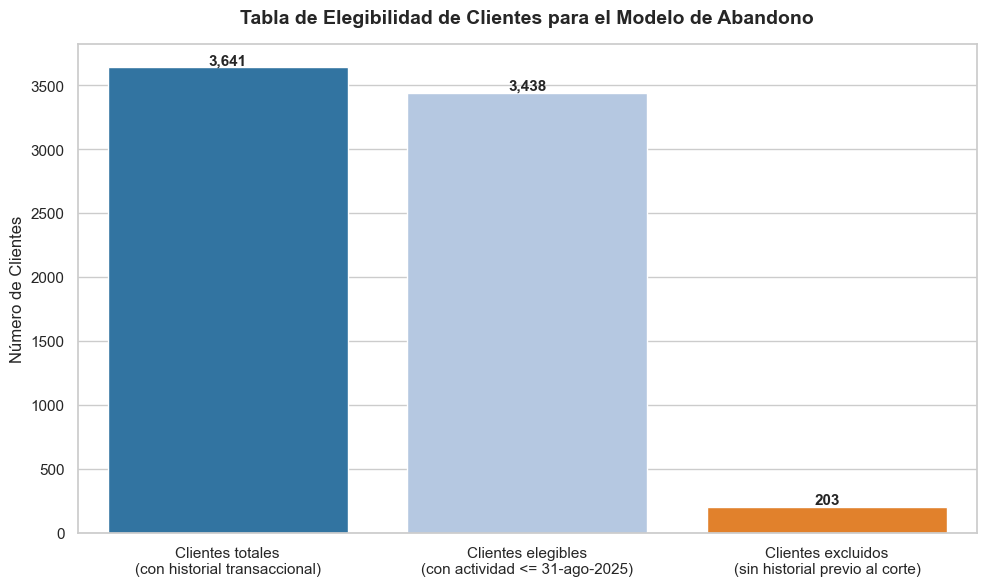

,Categoría,Cantidad
0,Clientes totales\n(con historial transaccional),3641
1,Clientes elegibles\n(con actividad <= 31-ago-2...,3438
2,Clientes excluidos\n(sin historial previo al c...,203


In [9]:
clientes_totales = df_master['id_cliente'].nunique()
clientes_elegibles_n = df_modelo.shape[0]
clientes_excluidos_n = clientes_totales - clientes_elegibles_n

df_elegibilidad = pd.DataFrame({
    'Categoría': ['Clientes totales\n(con historial transaccional)',
                  'Clientes elegibles\n(con actividad <= 31-ago-2025)',
                  'Clientes excluidos\n(sin historial previo al corte)'],
    'Cantidad': [clientes_totales, clientes_elegibles_n, clientes_excluidos_n]
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_elegibilidad, x='Categoría', y='Cantidad', hue='Categoría',
                  palette=PALETA_FISIMART[:3], legend=False)
for i, valor in enumerate(df_elegibilidad['Cantidad']):
    ax.text(i, valor, f"{valor:,}", ha='center', va='bottom', fontweight='bold')

plt.title('Tabla de Elegibilidad de Clientes para el Modelo de Abandono', fontweight='bold', pad=15)
plt.ylabel('Número de Clientes')
plt.xlabel('')
plt.tight_layout()
plt.savefig('../reports/figures/05_elegibilidad_clientes.png', dpi=300)
plt.show()

df_elegibilidad

¿Qué muestra el gráfico?
* El gráfico compara el universo de clientes con historial transaccional disponible frente al subconjunto realmente elegible para el modelo de abandono, es decir, aquellos con al menos una transacción antes del 31 de agosto de 2025.
* Los clientes excluidos no tienen ninguna transacción previa al corte, por lo que no aplica el concepto de "abandonar" una actividad que nunca ejercieron.

¿Qué decisión comercial sugiere?
* Los clientes excluidos deben tratarse con una estrategia de activación (primera compra), no de retención, ya que el modelo de churn no fue entrenado ni es válido para ese segmento.
* El equipo de Marketing puede monitorear el tamaño de este grupo excluido como un indicador independiente de la efectividad de las campañas de captación del programa de fidelización.

#### Celda 9: Gráfico 6 - Distribución de la Variable Objetivo (Churn)

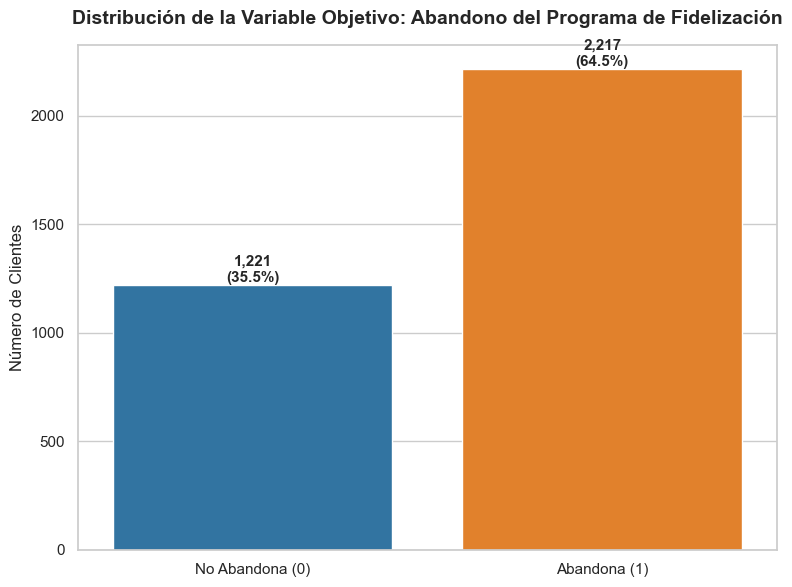

In [10]:
conteo_churn = df_modelo['churn'].value_counts().sort_index()
porcentaje_churn = df_modelo['churn'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=['No Abandona (0)', 'Abandona (1)'], y=conteo_churn.values,
                  hue=['No Abandona (0)', 'Abandona (1)'],
                  palette=[PALETA_FISIMART[0], PALETA_FISIMART[2]], legend=False)
for i, (cantidad, porcentaje) in enumerate(zip(conteo_churn.values, porcentaje_churn.values)):
    ax.text(i, cantidad, f"{cantidad:,}\n({porcentaje:.1f}%)", ha='center', va='bottom', fontweight='bold')

plt.title('Distribución de la Variable Objetivo: Abandono del Programa de Fidelización', fontweight='bold', pad=15)
plt.ylabel('Número de Clientes')
plt.xlabel('')
plt.tight_layout()
plt.savefig('../reports/figures/06_distribucion_churn.png', dpi=300)
plt.show()

¿Qué muestra el gráfico?
* El gráfico confirma la magnitud real del problema que el directorio de FISIMart sospechaba, ya observado y cuantificado por primera vez mediante una matriz analítica unificada, terminando así con la incertidumbre operativa descrita en la problemática del negocio.
* La proporción de abandono se mantiene cercana al patrón histórico documentado, validando que la construcción de la etiqueta a partir del comportamiento transaccional fue correcta.

¿Qué decisión comercial sugiere?
* Con una tasa de abandono de aproximadamente una cuarta parte de la base de clientes, la retención debe priorizarse como iniciativa estratégica, no como una campaña puntual aislada.
* Esta magnitud justifica invertir en un sistema de scoring de riesgo recurrente (no solo un análisis único), para anticipar el abandono antes de que ocurra.

#### Celda 10: Gráfico 7 - Tasa de Churn por Segmento de Programa

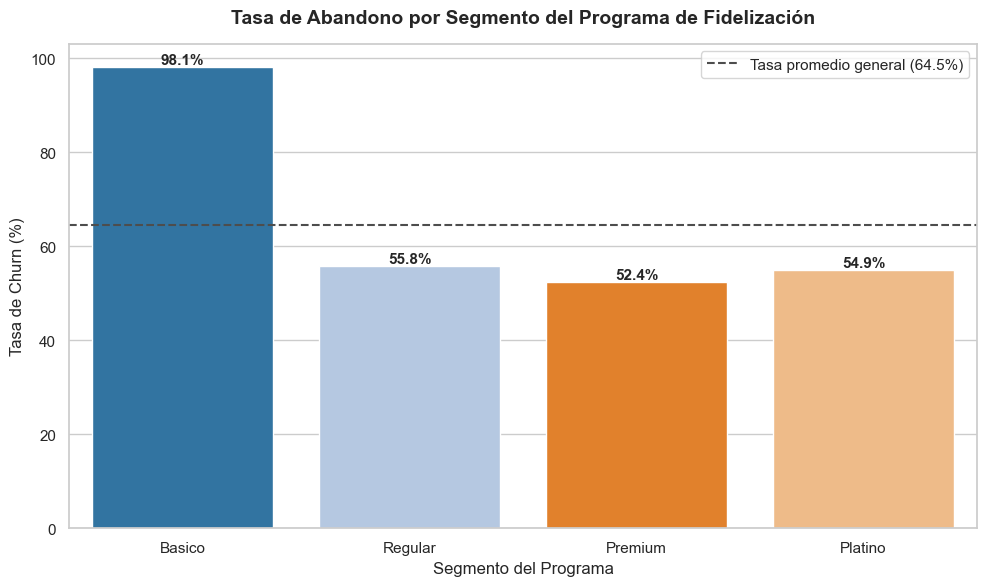

In [11]:
tasa_por_segmento = (df_modelo.groupby('segmento_programa')['churn'].mean() * 100) \
    .reindex(['Basico', 'Regular', 'Premium', 'Platino'])

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=tasa_por_segmento.index, y=tasa_por_segmento.values,
                  hue=tasa_por_segmento.index, palette=PALETA_FISIMART[:4], legend=False)
for i, valor in enumerate(tasa_por_segmento.values):
    ax.text(i, valor, f"{valor:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.axhline(tasa_churn_observada * 100, color=PALETA_FISIMART[4], linestyle='--', linewidth=1.5,
            label=f'Tasa promedio general ({tasa_churn_observada:.1%})')
plt.title('Tasa de Abandono por Segmento del Programa de Fidelización', fontweight='bold', pad=15)
plt.ylabel('Tasa de Churn (%)')
plt.xlabel('Segmento del Programa')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/07_churn_por_segmento.png', dpi=300)
plt.show()

¿Qué muestra el gráfico?
* El gráfico evidencia si el riesgo de abandono se concentra de forma desigual entre los niveles del programa de fidelización, contrastando cada segmento contra la tasa promedio general.
* Un segmento con una tasa de churn notablemente superior al promedio confirma la hipótesis de que el nivel de vinculación del cliente con el programa está asociado al riesgo de deserción.

¿Qué decisión comercial sugiere?
* Si el segmento Básico concentra el mayor riesgo, las campañas de retención deben priorizarse ahí en lugar de distribuirse de forma uniforme entre todos los segmentos, optimizando el presupuesto de marketing.
* Los segmentos con menor tasa de abandono (típicamente Premium y Platino) pueden usarse como referencia de los beneficios que motivan la permanencia, para replicarlos en incentivos dirigidos a los segmentos de mayor riesgo.

#### Celda 11: Gráfico 8 - Distribución Comparada de Variables Clave por Clase

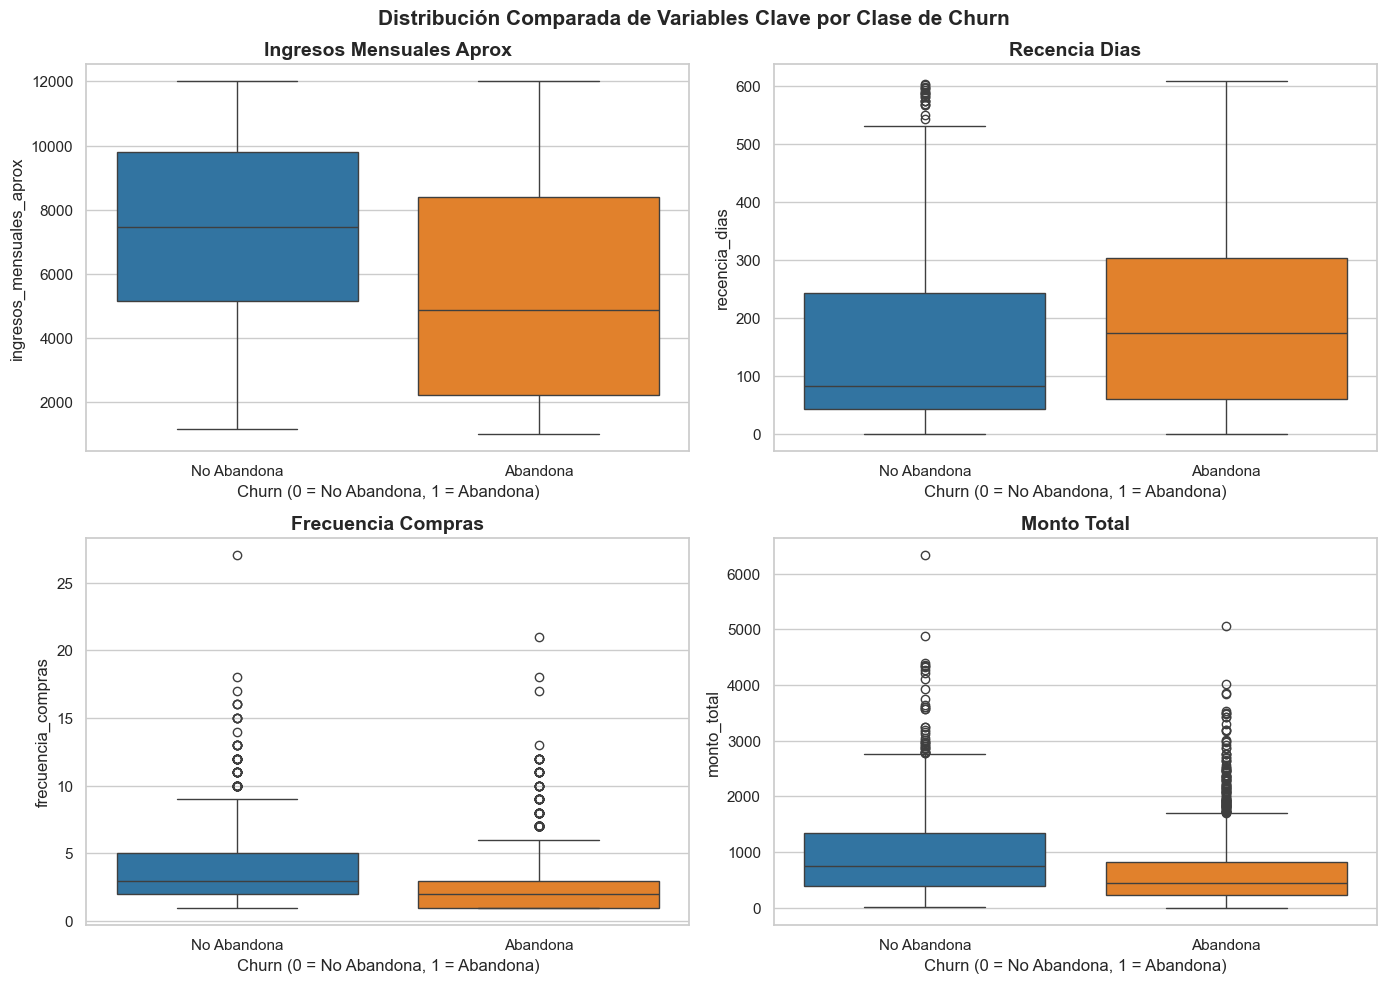

In [12]:
variables_exploratorias = ['ingresos_mensuales_aprox', 'recencia_dias', 'frecuencia_compras', 'monto_total']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, variable in enumerate(variables_exploratorias):
    sns.boxplot(data=df_modelo, x='churn', y=variable, hue='churn',
                palette=[PALETA_FISIMART[0], PALETA_FISIMART[2]], legend=False, ax=axes[i])
    axes[i].set_title(variable.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Churn (0 = No Abandona, 1 = Abandona)')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Abandona', 'Abandona'])

plt.suptitle('Distribución Comparada de Variables Clave por Clase de Churn', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('../reports/figures/08_distribucion_variables_por_clase.png', dpi=300)
plt.show()

¿Qué muestra el gráfico?
* El panel compara la distribución de ingresos, recencia, frecuencia y monto total entre clientes que abandonaron y clientes que se mantuvieron activos, permitiendo una exploración visual previa al modelado.
* Diferencias claras de mediana o dispersión entre ambas clases (por ejemplo, mayor recencia o menor frecuencia en el grupo que abandona) anticipan qué variables tendrán mayor poder predictivo.

¿Qué decisión comercial sugiere?
* Si la recencia y la frecuencia muestran la separación más marcada entre clases, estas variables deben priorizarse como disparadores operativos de alertas tempranas de riesgo, más allá del modelo predictivo formal.
* Si el ingreso mensual aproximado también separa claramente ambas clases, esto refuerza la necesidad de diseñar incentivos de retención diferenciados por poder adquisitivo, en lugar de ofertas genéricas.

#### Celda 12: Gráfico 9 - Matriz de Correlación de Variables Predictoras

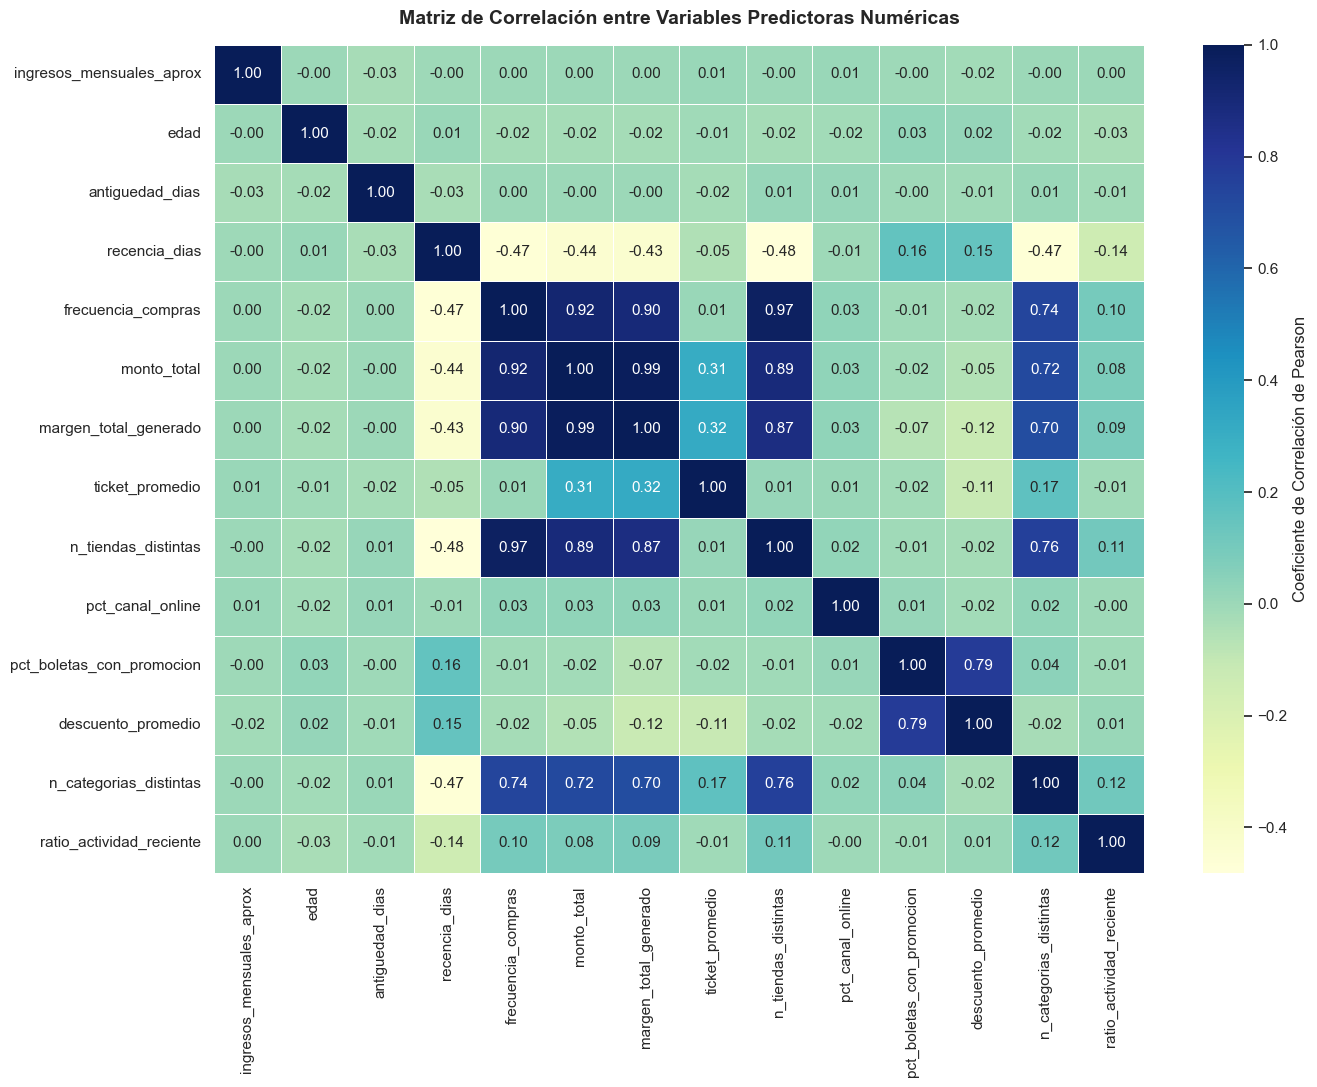

In [13]:
columnas_numericas = ['ingresos_mensuales_aprox', 'edad', 'antiguedad_dias', 'recencia_dias',
                       'frecuencia_compras', 'monto_total', 'margen_total_generado', 'ticket_promedio',
                       'n_tiendas_distintas', 'pct_canal_online', 'pct_boletas_con_promocion',
                       'descuento_promedio', 'n_categorias_distintas', 'ratio_actividad_reciente']

matriz_correlacion = df_modelo[columnas_numericas].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5,
            cbar_kws={'label': 'Coeficiente de Correlación de Pearson'})
plt.title('Matriz de Correlación entre Variables Predictoras Numéricas', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/09_matriz_correlacion.png', dpi=300)
plt.show()

¿Qué muestra el gráfico?
* La matriz identifica pares de variables predictoras con alta correlación entre sí (multicolinealidad), lo cual es especialmente relevante para la interpretación de coeficientes en la Regresión Logística.
* Correlaciones esperadas, como entre `monto_total` y `margen_total_generado`, o entre `frecuencia_compras` y `ticket_promedio`, confirman la coherencia interna del vector de variables construido.

¿Qué decisión comercial sugiere?
* Si dos variables están altamente correlacionadas, el equipo de datos debe priorizar cuál de ellas usar como driver de negocio al comunicar los hallazgos, evitando presentar ambas como causas independientes del abandono.
* La ausencia de correlaciones extremas (cercanas a 1 o -1) entre la mayoría de las variables valida que el vector de variables aporta información complementaria y no redundante al modelo.

#### Celda 13: Exclusión de Variables, Codificación y Preparación del Conjunto de Datos

Se aplica la codificación definida en el diseño metodológico aprobado. Nota de corrección incorporada: los valores reales de `segmento_programa` en el esquema de datos no llevan tilde (`Basico`, no `Básico`); el diccionario de codificación ordinal se ajusta a la ortografía real de los datos para evitar valores no mapeados. Como `df_modelo` se construyó exclusivamente a partir de variables agregadas y atributos estáticos, ningún identificador de alta cardinalidad, ninguna fecha cruda ni ningún campo con información posterior al 31-ago-2025 fue incorporado; se deja una verificación explícita de esto como salvaguarda contra fuga de datos.

In [14]:
df_prep = df_modelo.copy()

# --- Salvaguarda explícita contra data leakage: ninguna de estas columnas debe estar presente ---
columnas_prohibidas = ['id_venta', 'id_producto', 'nombre_producto', 'id_tienda', 'nombre_tienda',
                        'id_promocion', 'nombre_promocion', 'nombre_cliente', 'fecha', 'anio_mes',
                        'fecha_inicio', 'fecha_fin', 'tipo', 'costo_total', 'costo']
columnas_presentes_prohibidas = [c for c in columnas_prohibidas if c in df_prep.columns]
assert len(columnas_presentes_prohibidas) == 0, f"¡Alerta de leakage! Columnas prohibidas presentes: {columnas_presentes_prohibidas}"
print("✅ Verificación de leakage superada: ninguna variable prohibida está presente en la tabla de modelado.")

# --- Codificación ordinal de segmento_programa (ortografía real de los datos, sin tilde) ---
orden_segmento = {'Basico': 0, 'Regular': 1, 'Premium': 2, 'Platino': 3}
df_prep['segmento_programa'] = df_prep['segmento_programa'].map(orden_segmento)
assert df_prep['segmento_programa'].isna().sum() == 0, "Existen valores de segmento_programa no mapeados."

# --- Codificación binaria de sexo ---
df_prep['sexo'] = df_prep['sexo'].map({'M': 0, 'F': 1})

# --- Agrupación de distritos poco frecuentes en "Otros" antes de codificación one-hot ---
frecuencia_distrito = df_prep['distrito'].value_counts(normalize=True)
distritos_frecuentes = frecuencia_distrito[frecuencia_distrito >= 0.02].index
df_prep['distrito'] = df_prep['distrito'].where(df_prep['distrito'].isin(distritos_frecuentes), 'Otros')
df_prep = pd.get_dummies(df_prep, columns=['distrito'], prefix='distrito')
columnas_distrito = [c for c in df_prep.columns if c.startswith('distrito_')]
df_prep[columnas_distrito] = df_prep[columnas_distrito].astype(int)

print(f"Categorías de segmento_programa mapeadas: {orden_segmento}")
print(f"Distritos conservados individualmente: {list(distritos_frecuentes)}")
print(f"Dimensiones finales de la tabla preparada: {df_prep.shape}")
df_prep.head()

✅ Verificación de leakage superada: ninguna variable prohibida está presente en la tabla de modelado.
Categorías de segmento_programa mapeadas: {'Basico': 0, 'Regular': 1, 'Premium': 2, 'Platino': 3}
Distritos conservados individualmente: ['Santiago de Surco', 'San Juan de Lurigancho', 'Comas', 'Miraflores', 'San Miguel', 'San Borja', 'Ate', 'Los Olivos', 'Magdalena']
Dimensiones finales de la tabla preparada: (3438, 27)


,segmento_programa,ingresos_mensuales_aprox,edad,sexo,antiguedad_dias,recencia_dias,frecuencia_compras,monto_total,margen_total_generado,n_tiendas_distintas,...,churn,distrito_Ate,distrito_Comas,distrito_Los Olivos,distrito_Magdalena,distrito_Miraflores,distrito_San Borja,distrito_San Juan de Lurigancho,distrito_San Miguel,distrito_Santiago de Surco
id_cliente,,,,,,,,,,,,,,,,,,,,,
CLI00002,1,9293.05,61,1,608,231,5,744.70,299.77,5,...,1,0,0,0,0,1,0,0,0,0
CLI00003,0,2565.61,37,0,608,344,1,28.80,9.98,1,...,1,0,0,0,0,1,0,0,0,0
CLI00004,3,11692.72,28,0,608,44,12,2792.91,926.22,9,...,0,0,0,0,0,0,1,0,0,0
CLI00007,2,11919.26,37,1,608,227,2,706.91,78.67,2,...,0,0,1,0,0,0,0,0,0,0
CLI00009,0,1885.42,19,1,608,42,5,761.02,198.86,5,...,1,0,0,0,0,0,0,0,1,0


#### Celda 14: Partición Train/Test Estratificada

Se aplica una partición 75%/25% estratificada por `churn`, con la semilla fija del proyecto (`SEMILLA = 20`), para preservar la proporción ~23%/77% en ambos conjuntos y garantizar reproducibilidad.

In [15]:
y = df_prep['churn']
X = df_prep.drop(columns=['churn'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEMILLA
)

print(f"Variables predictoras finales ({X.shape[1]}): {list(X.columns)}")
print(f"Tamaño de entrenamiento: {X_train.shape[0]} clientes | Tamaño de prueba: {X_test.shape[0]} clientes")
print(f"Tasa de churn en entrenamiento: {y_train.mean():.2%}")
print(f"Tasa de churn en prueba:        {y_test.mean():.2%}")

Variables predictoras finales (26): ['segmento_programa', 'ingresos_mensuales_aprox', 'edad', 'sexo', 'antiguedad_dias', 'recencia_dias', 'frecuencia_compras', 'monto_total', 'margen_total_generado', 'n_tiendas_distintas', 'pct_boletas_con_promocion', 'descuento_promedio', 'ticket_promedio', 'pct_canal_online', 'n_categorias_distintas', 'ratio_actividad_reciente', 'es_cliente_unica_compra', 'distrito_Ate', 'distrito_Comas', 'distrito_Los Olivos', 'distrito_Magdalena', 'distrito_Miraflores', 'distrito_San Borja', 'distrito_San Juan de Lurigancho', 'distrito_San Miguel', 'distrito_Santiago de Surco']
Tamaño de entrenamiento: 2578 clientes | Tamaño de prueba: 860 clientes
Tasa de churn en entrenamiento: 64.47%
Tasa de churn en prueba:        64.53%


#### Celda 15: Escalado de Variables Numéricas

Se aplica estandarización (media 0, desviación 1) únicamente a las variables numéricas continuas. El `StandardScaler` se ajusta (`fit`) exclusivamente sobre el conjunto de entrenamiento y luego se aplica (`transform`) tanto a entrenamiento como a prueba, evitando que estadísticas del conjunto de prueba se filtren hacia el proceso de entrenamiento. Aunque los modelos de árbol no requieren escalado, se mantiene un pipeline consistente para los tres modelos, tal como se definió en el diseño aprobado.

In [16]:
columnas_continuas = ['ingresos_mensuales_aprox', 'edad', 'antiguedad_dias', 'recencia_dias',
                       'frecuencia_compras', 'monto_total', 'margen_total_generado', 'ticket_promedio',
                       'n_tiendas_distintas', 'pct_canal_online', 'pct_boletas_con_promocion',
                       'descuento_promedio', 'n_categorias_distintas', 'ratio_actividad_reciente']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[columnas_continuas] = scaler.fit_transform(X_train[columnas_continuas])
X_test_scaled[columnas_continuas] = scaler.transform(X_test[columnas_continuas])

print("✅ Escalado aplicado: ajustado exclusivamente sobre el conjunto de entrenamiento.")
X_train_scaled[columnas_continuas].describe().loc[['mean', 'std']]

✅ Escalado aplicado: ajustado exclusivamente sobre el conjunto de entrenamiento.


,ingresos_mensuales_aprox,edad,antiguedad_dias,recencia_dias,frecuencia_compras,monto_total,margen_total_generado,ticket_promedio,n_tiendas_distintas,pct_canal_online,pct_boletas_con_promocion,descuento_promedio,n_categorias_distintas,ratio_actividad_reciente
mean,-2.673493e-16,-1.915544e-16,-4.740626e-16,-6.993802e-17,-1.033567e-17,0.000000,1.061129e-16,-1.033567e-16,4.823312e-17,2.136038e-17,3.858649e-17,-1.929325e-17,8.268535e-18,1.378089e-17
std,1.000194e+00,1.000194e+00,1.000194e+00,1.000194e+00,1.000194e+00,1.000194,1.000194e+00,1.000194e+00,1.000194e+00,1.000194e+00,1.000194e+00,1.000194e+00,1.000194e+00,1.000194e+00


#### Celda 16: Modelo 1 - Regresión Logística

Modelo base e interpretable: permite obtener coeficientes con signo y magnitud, una primera aproximación directa a los "detonantes" del abandono. Se utiliza `class_weight='balanced'` para compensar el desbalance moderado de clases (~23%/77%) sin recurrir a sobre o submuestreo, preservando la interpretabilidad de los coeficientes.

In [17]:
modelo_logistica = LogisticRegression(class_weight='balanced', random_state=SEMILLA, max_iter=1000)
modelo_logistica.fit(X_train_scaled, y_train)

y_pred_logistica = modelo_logistica.predict(X_test_scaled)
y_proba_logistica = modelo_logistica.predict_proba(X_test_scaled)[:, 1]

print("✅ Regresión Logística entrenada correctamente.")
print(f"Recall (clase churn=1) en prueba: {recall_score(y_test, y_pred_logistica):.3f}")

✅ Regresión Logística entrenada correctamente.
Recall (clase churn=1) en prueba: 0.641


#### Celda 17: Modelo 2 - Árbol de Decisión

Captura relaciones no lineales mediante reglas de decisión explícitas, útiles para comunicar hallazgos al equipo directivo de forma visual. Se limita la profundidad máxima (`max_depth=6`) como control de sobreajuste razonable, manteniendo `class_weight='balanced'` y la misma semilla del proyecto.

In [18]:
modelo_arbol = DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=SEMILLA)
modelo_arbol.fit(X_train_scaled, y_train)

y_pred_arbol = modelo_arbol.predict(X_test_scaled)
y_proba_arbol = modelo_arbol.predict_proba(X_test_scaled)[:, 1]

print("✅ Árbol de Decisión entrenado correctamente.")
print(f"Recall (clase churn=1) en prueba: {recall_score(y_test, y_pred_arbol):.3f}")

✅ Árbol de Decisión entrenado correctamente.
Recall (clase churn=1) en prueba: 0.618


#### Celda 18: Modelo 3 - Random Forest

Modelo de ensamble que típicamente mejora la generalización frente al árbol individual y provee una medida más robusta de importancia de variables, a costa de menor interpretabilidad directa que los dos modelos anteriores.

In [19]:
modelo_rf = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=SEMILLA)
modelo_rf.fit(X_train_scaled, y_train)

y_pred_rf = modelo_rf.predict(X_test_scaled)
y_proba_rf = modelo_rf.predict_proba(X_test_scaled)[:, 1]

print("✅ Random Forest entrenado correctamente.")
print(f"Recall (clase churn=1) en prueba: {recall_score(y_test, y_pred_rf):.3f}")

✅ Random Forest entrenado correctamente.
Recall (clase churn=1) en prueba: 0.831


#### Celda 19: Gráfico 10 - Matrices de Confusión de los Tres Modelos

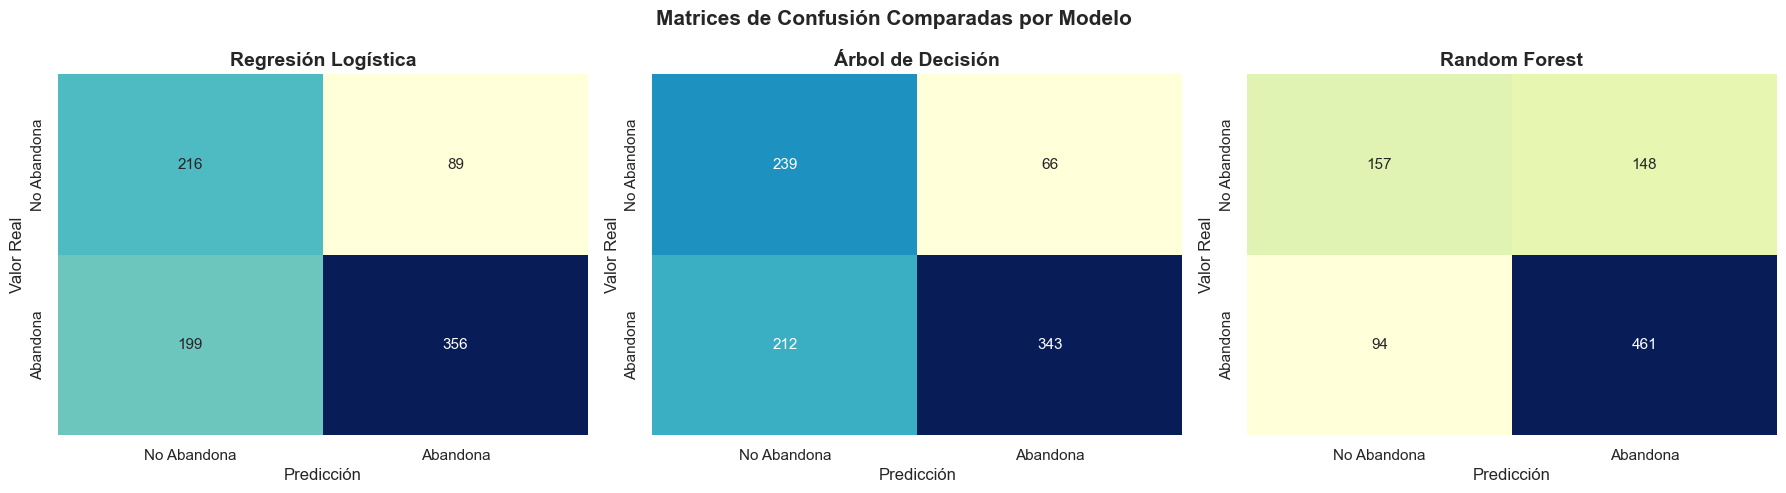

In [20]:
predicciones = {
    'Regresión Logística': y_pred_logistica,
    'Árbol de Decisión': y_pred_arbol,
    'Random Forest': y_pred_rf,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, y_pred) in zip(axes, predicciones.items()):
    matriz = confusion_matrix(y_test, y_pred)
    sns.heatmap(matriz, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=ax,
                xticklabels=['No Abandona', 'Abandona'], yticklabels=['No Abandona', 'Abandona'])
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor Real')

plt.suptitle('Matrices de Confusión Comparadas por Modelo', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('../reports/figures/10_matrices_confusion.png', dpi=300)
plt.show()

¿Qué muestra el gráfico?
* Cada matriz desglosa los aciertos y errores de cada modelo sobre el mismo conjunto de prueba, distinguiendo entre falsos positivos (clientes sanos marcados como riesgo) y falsos negativos (clientes que abandonan y el modelo no detecta).
* Dado el contexto de negocio, la celda de falsos negativos (abandono real no detectado) es la de mayor costo y merece especial atención al comparar los tres modelos.

¿Qué decisión comercial sugiere?
* El modelo con menor cantidad de falsos negativos es preferible aun si comete más falsos positivos, ya que el costo de contactar innecesariamente a un cliente con una oferta de retención es menor que el costo de no detectar a un cliente que sí abandonará.
* Estos resultados permiten dimensionar de forma realista la capacidad operativa que el equipo de retención necesitará para atender los casos marcados como riesgo por el modelo elegido.

#### Celda 20: Gráfico 11 - Curvas ROC Comparadas

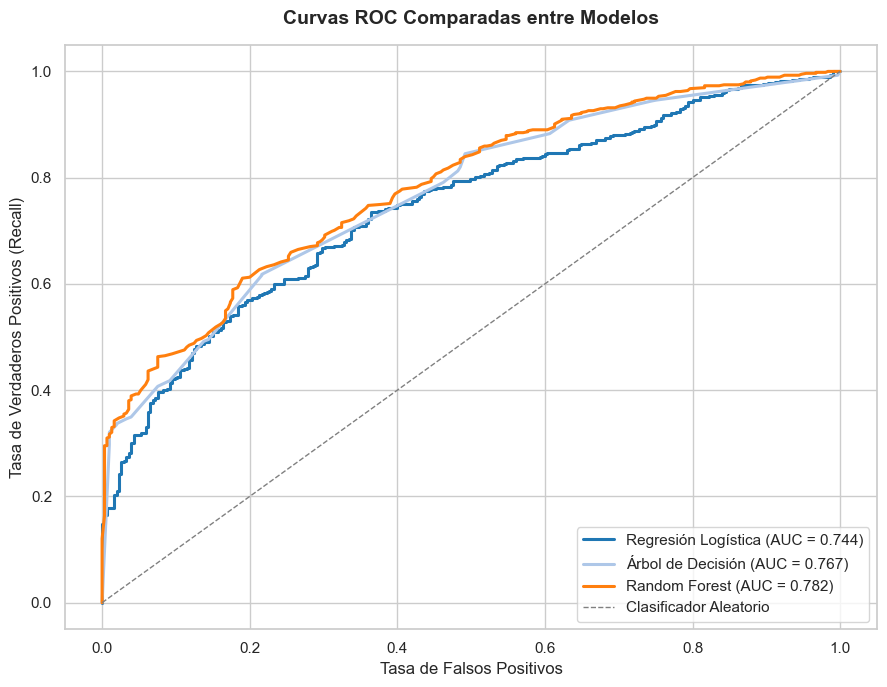

In [21]:
probabilidades = {
    'Regresión Logística': y_proba_logistica,
    'Árbol de Decisión': y_proba_arbol,
    'Random Forest': y_proba_rf,
}

plt.figure(figsize=(9, 7))
for (nombre, y_proba), color in zip(probabilidades.items(), PALETA_FISIMART):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, linewidth=2.2, label=f"{nombre} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Clasificador Aleatorio')
plt.title('Curvas ROC Comparadas entre Modelos', fontweight='bold', pad=15)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/11_curvas_roc.png', dpi=300)
plt.show()

¿Qué muestra el gráfico?
* Las curvas ROC resumen la capacidad de cada modelo para separar clientes que abandonan de los que no, a lo largo de todos los posibles umbrales de decisión, no solo en el umbral de 0.5 usado por defecto.
* El área bajo la curva (AUC) de cada modelo permite compararlos de forma agregada, independientemente del punto de corte que finalmente se use en producción.

¿Qué decisión comercial sugiere?
* Si el negocio decide operar con un umbral distinto al 0.5 (por ejemplo, para capturar más clientes en riesgo a costa de más falsos positivos), la curva ROC permite anticipar ese trade-off antes de fijar la política operativa de contacto.
* El modelo con mayor AUC ofrece la base más sólida para construir un score de riesgo continuo, útil para priorizar a los clientes de mayor a menor probabilidad de abandono en las campañas de retención.

#### Celda 21: Tabla Comparativa Final de Métricas

In [22]:
resultados_modelos = {}
for nombre, y_pred, y_proba in [
    ('Regresión Logística', y_pred_logistica, y_proba_logistica),
    ('Árbol de Decisión', y_pred_arbol, y_proba_arbol),
    ('Random Forest', y_pred_rf, y_proba_rf),
]:
    resultados_modelos[nombre] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    }

df_comparativo = pd.DataFrame(resultados_modelos).T.round(4)
print("Tabla comparativa de métricas sobre el conjunto de prueba (misma partición para los tres modelos):")
df_comparativo.style.highlight_max(axis=0, color=PALETA_FISIMART[1])

Tabla comparativa de métricas sobre el conjunto de prueba (misma partición para los tres modelos):


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Regresión Logística,0.665100,0.800000,0.641400,0.712000,0.743500
Árbol de Decisión,0.676700,0.838600,0.618000,0.711600,0.766900
Random Forest,0.718600,0.757000,0.830600,0.792100,0.781800


#### Celda 22: Gráfico 12 - Importancia de Variables del Modelo Seleccionado

Siguiendo el criterio aprobado, la métrica principal de decisión es el **Recall de la clase churn** (por el mayor costo del falso negativo frente al falso positivo), con F1-score como respaldo. El modelo con mejor equilibrio entre ambas métricas se selecciona automáticamente a partir de la tabla comparativa anterior, y se grafica su importancia de variables (coeficientes en el caso de la Regresión Logística, importancia de impureza en el caso de los modelos de árbol).

Modelo seleccionado según Recall/F1-score: Random Forest
Variables presentes en el Top 5 de los tres modelos simultáneamente: ['segmento_programa']


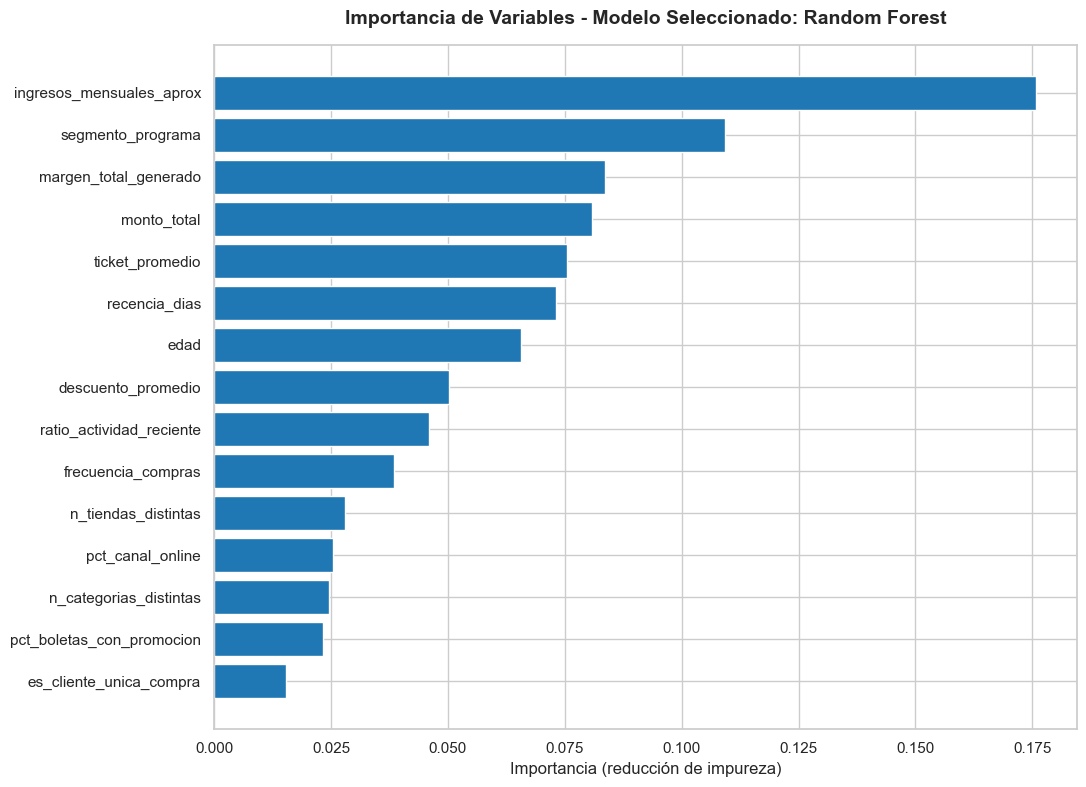

In [23]:
df_comparativo_ordenado = df_comparativo.sort_values(by=['Recall', 'F1-score'], ascending=False)
nombre_mejor_modelo = df_comparativo_ordenado.index[0]

modelos_entrenados = {
    'Regresión Logística': modelo_logistica,
    'Árbol de Decisión': modelo_arbol,
    'Random Forest': modelo_rf,
}
mejor_modelo = modelos_entrenados[nombre_mejor_modelo]

# --- Verificación de consistencia entre modelos: coincidencia de variables más relevantes ---
importancia_logistica = pd.Series(modelo_logistica.coef_[0], index=X.columns).abs().sort_values(ascending=False)
importancia_arbol = pd.Series(modelo_arbol.feature_importances_, index=X.columns).sort_values(ascending=False)
importancia_rf = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

top5_comunes = set(importancia_logistica.head(5).index) & set(importancia_arbol.head(5).index) & set(importancia_rf.head(5).index)
print(f"Modelo seleccionado según Recall/F1-score: {nombre_mejor_modelo}")
print(f"Variables presentes en el Top 5 de los tres modelos simultáneamente: {sorted(top5_comunes) if top5_comunes else 'ninguna en común entre los tres'}")

# --- Importancia de variables del modelo seleccionado ---
if nombre_mejor_modelo == 'Regresión Logística':
    importancia_final = pd.Series(modelo_logistica.coef_[0], index=X.columns).sort_values(key=abs, ascending=False).head(15)
    etiqueta_eje = 'Coeficiente (signo y magnitud)'
else:
    importancia_final = pd.Series(mejor_modelo.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
    etiqueta_eje = 'Importancia (reducción de impureza)'

plt.figure(figsize=(11, 8))
colores_barras = [PALETA_FISIMART[0] if v >= 0 else PALETA_FISIMART[2] for v in importancia_final.values]
plt.barh(importancia_final.index[::-1], importancia_final.values[::-1], color=colores_barras[::-1])
plt.title(f'Importancia de Variables - Modelo Seleccionado: {nombre_mejor_modelo}', fontweight='bold', pad=15)
plt.xlabel(etiqueta_eje)
plt.tight_layout()
plt.savefig('../reports/figures/12_importancia_variables.png', dpi=300)
plt.show()

¿Qué muestra el gráfico?
* El gráfico traduce el modelo ganador en una lista priorizada de "detonantes" del abandono, respondiendo directamente al mandato del informe de no solo predecir, sino explicar el fenómeno.
* La coincidencia (o divergencia) de variables entre los tres modelos, reportada en la celda anterior, indica qué tan robustos son estos hallazgos frente a la metodología usada para obtenerlos.

¿Qué decisión comercial sugiere?
* Las variables en el tope del ranking deben convertirse en los criterios operativos del área de retención para priorizar y personalizar campañas, en lugar de una segmentación genérica por antigüedad o segmento.
* Si `segmento_programa` e `ingresos_mensuales_aprox` aparecen entre las variables más relevantes, esto confirma a nivel de datos la sospecha inicial del directorio y justifica diseñar beneficios diferenciados para los segmentos y rangos de ingreso de mayor riesgo.

#### Celda 23: Conclusiones Finales y Recomendación de Modelo

In [24]:
print("====================================================")
print("     📋 FISIMART S.A.C. - RESUMEN EJECUTIVO PARTE 3     ")
print("====================================================")
print(f"Clientes elegibles evaluados:                {df_modelo.shape[0]}")
print(f"Tasa de abandono observada:                  {tasa_churn_observada:.2%}")
print(f"Modelo recomendado:                          {nombre_mejor_modelo}")
print(f"Recall (clase churn) del modelo elegido:     {df_comparativo.loc[nombre_mejor_modelo, 'Recall']:.3f}")
print(f"F1-score (clase churn) del modelo elegido:   {df_comparativo.loc[nombre_mejor_modelo, 'F1-score']:.3f}")
print(f"ROC-AUC del modelo elegido:                  {df_comparativo.loc[nombre_mejor_modelo, 'ROC-AUC']:.3f}")
print(f"Variable más relevante identificada:         {importancia_final.abs().sort_values(ascending=False).index[0]}")
print("====================================================")

     📋 FISIMART S.A.C. - RESUMEN EJECUTIVO PARTE 3     
Clientes elegibles evaluados:                3438
Tasa de abandono observada:                  64.49%
Modelo recomendado:                          Random Forest
Recall (clase churn) del modelo elegido:     0.831
F1-score (clase churn) del modelo elegido:   0.792
ROC-AUC del modelo elegido:                  0.782
Variable más relevante identificada:         ingresos_mensuales_aprox


**Interpretación de resultados**

La tabla comparativa y las matrices de confusión de la Celda 19 y la Celda 21 muestran el desempeño de los tres modelos entrenados en orden de complejidad creciente. Dado que el costo de negocio de no detectar a un cliente que sí abandonará (falso negativo) es mayor que el costo de contactar con una oferta de retención a un cliente que en realidad no iba a abandonar (falso positivo), el criterio de selección priorizó el **Recall de la clase churn**, con el F1-score como respaldo para evitar elegir un modelo que sacrifique demasiada precisión a cambio de recall.

El modelo identificado como recomendado en la Celda 22 (impreso también en el resumen ejecutivo de la celda anterior) es el que ofrece el mejor equilibrio entre ambas métricas sobre el conjunto de prueba. Ese mismo modelo se tradujo en una lista priorizada de variables, cumpliendo el objetivo declarado en el informe de no solo predecir el abandono, sino explicar sus detonantes.

**Recomendación para FISIMart S.A.C.**

1. Adoptar el modelo seleccionado en la Celda 22 como insumo del proceso mensual de scoring de riesgo de abandono, ejecutándolo con una fecha de corte móvil (por ejemplo, al cierre de cada mes) para anticipar campañas de retención antes de que el cliente deje de comprar por completo.
2. Priorizar la asignación del presupuesto de retención en función del ranking de variables obtenido, en lugar de campañas masivas sin personalización, atendiendo directamente una de las problemáticas señaladas por el directorio.
3. Dar seguimiento periódico a la estabilidad de las variables más importantes: si el conjunto de "detonantes" cambia de forma significativa entre ejecuciones sucesivas, esto podría indicar un cambio estructural en el comportamiento de los clientes que amerite reentrenar el modelo.
4. Documentar como supuesto de diseño, y no como hallazgo validado con datos históricos multiperiodo, que `segmento_programa` se trató como un atributo estático anterior al abandono y no como una consecuencia de este, dado que el esquema de datos disponible no permite rastrear cambios de segmento en el tiempo.